In [1]:
# 차원축소
# (n, 784) => (n, 64)
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

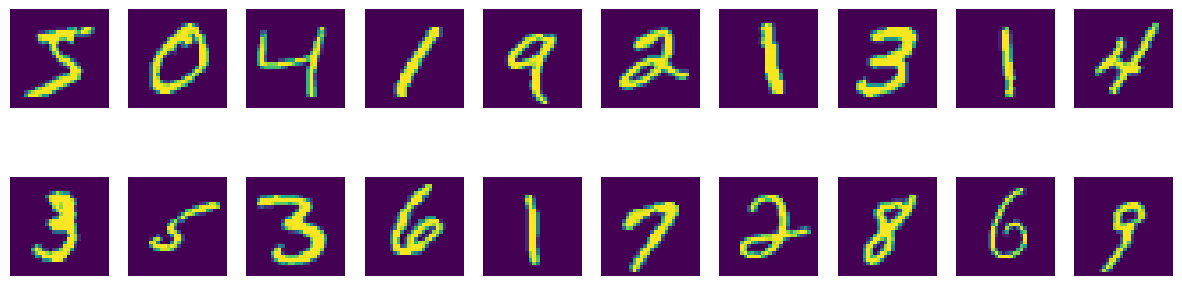

In [2]:
# x_train의 20개 이미지를 표시
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
for i in range(20):
    plt.subplot(2, 10, (i+1))
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()

In [3]:
# (n, 28, 28) => (n, 784)
x_train1 = x_train.reshape(-1, 28*28)
x_test1 = x_test.reshape(-1, 28*28)

x_train1.shape, x_test1.shape

((60000, 784), (10000, 784))

In [4]:
# 차원축소
# (n, 784) => (n, 64) 로 변환
from sklearn.decomposition import PCA
pca = PCA(n_components=64)
pca.fit(x_train1)

,n_components,64
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [5]:
# 784개의 특성을 64로 줄이면 86%로의 설명률
import numpy as np
np.sum(pca.explained_variance_ratio_)

np.float64(0.8619526700710813)

In [6]:
x_train1_pca = pca.transform(x_train1)
x_train1_pca.shape

(60000, 64)

In [7]:
# 복원하기
# (n, 64) => (n, 784)
x_train1_inverse = pca.inverse_transform(x_train1_pca)
x_train1_inverse.shape

(60000, 784)

In [8]:
# 복원한 x_train1_inverse와 원본 x_train1 비교
x_train1_inverse.shape, x_train1.shape

((60000, 784), (60000, 784))

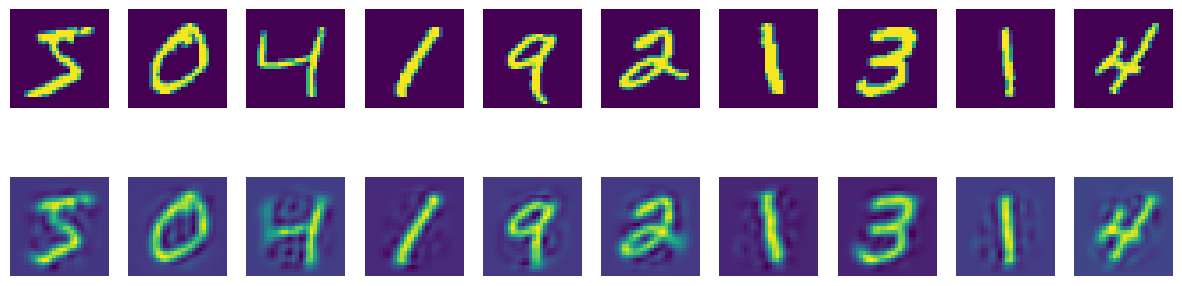

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
for i in range(10):
    plt.subplot(2, 10, (i+1))
    plt.imshow(x_train1[i].reshape(28,28))
    plt.axis('off')

    plt.subplot(2, 10, (i+1+10))
    plt.imshow(x_train1_inverse[i].reshape(28,28))
    plt.axis('off')

plt.show()

In [10]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(x_train1)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [11]:
import numpy as np
np.set_printoptions(suppress=True, precision=4)
pca.explained_variance_ratio_

array([0.097 , 0.071 , 0.0617, 0.0539, 0.0487, 0.0431, 0.0327, 0.0288,
       0.0276, 0.0236, 0.0211, 0.0202, 0.0172, 0.0169, 0.0158, 0.0148,
       0.0132, 0.0128, 0.0119, 0.0115, 0.0107, 0.0101, 0.0095, 0.0091,
       0.0088, 0.0084, 0.0081, 0.0079, 0.0074, 0.0069, 0.0066, 0.0065,
       0.006 , 0.0059, 0.0057, 0.0054, 0.0051, 0.0049, 0.0048, 0.0047,
       0.0046, 0.0044, 0.0042, 0.004 , 0.0038, 0.0038, 0.0036, 0.0035,
       0.0034, 0.0032, 0.0032, 0.0031, 0.003 , 0.0029, 0.0028, 0.0027,
       0.0027, 0.0026, 0.0025, 0.0024, 0.0024, 0.0024, 0.0023, 0.0022,
       0.0021, 0.0021, 0.002 , 0.002 , 0.0019, 0.0019, 0.0019, 0.0018,
       0.0018, 0.0017, 0.0017, 0.0016, 0.0016, 0.0016, 0.0015, 0.0014,
       0.0014, 0.0014, 0.0014, 0.0014, 0.0013, 0.0013, 0.0013, 0.0013,
       0.0012, 0.0012, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
       0.001 , 0.001 , 0.001 , 0.001 , 0.001 , 0.0009, 0.0009, 0.0009,
       0.0009, 0.0009, 0.0009, 0.0009, 0.0008, 0.0008, 0.0008, 0.0008,
      

In [12]:
for v in pca.explained_variance_ratio_:
    print(f"{v*100:.2f}")

9.70
7.10
6.17
5.39
4.87
4.31
3.27
2.88
2.76
2.36
2.11
2.02
1.72
1.69
1.58
1.48
1.32
1.28
1.19
1.15
1.07
1.01
0.95
0.91
0.88
0.84
0.81
0.79
0.74
0.69
0.66
0.65
0.60
0.59
0.57
0.54
0.51
0.49
0.48
0.47
0.46
0.44
0.42
0.40
0.38
0.38
0.36
0.35
0.34
0.32
0.32
0.31
0.30
0.29
0.28
0.27
0.27
0.26
0.25
0.24
0.24
0.24
0.23
0.22
0.21
0.21
0.20
0.20
0.19
0.19
0.19
0.18
0.18
0.17
0.17
0.16
0.16
0.16
0.15
0.14
0.14
0.14
0.14
0.14
0.13
0.13
0.13
0.13
0.12
0.12
0.12
0.11
0.11
0.11
0.11
0.11
0.10
0.10
0.10
0.10
0.10
0.09
0.09
0.09
0.09
0.09
0.09
0.09
0.08
0.08
0.08
0.08
0.08
0.08
0.08
0.08
0.07
0.07
0.07
0.07
0.07
0.07
0.07
0.07
0.07
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.06
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.05
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.04
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03
0.03


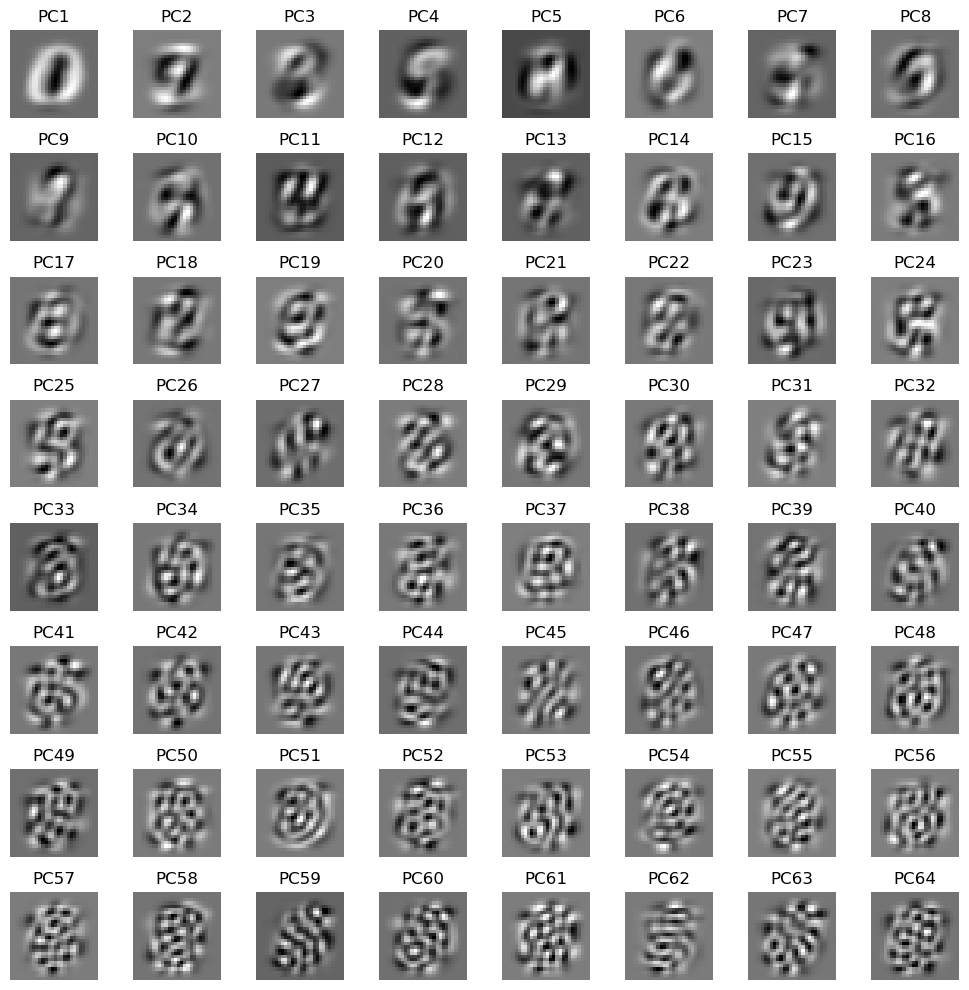

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    8, 8,
    figsize=(10,10)
)

for i, ax in enumerate(axes.flat):

    # 784 -> 28x28
    img = pca.components_[i].reshape(28, 28)

    ax.imshow(img, cmap='gray')

    ax.set_title(f'PC{i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()